# 6 Unsupervised Models

Using the same dataset, we will cluster players into injury risk archetypes such as durable young players, high-mileage veterans, or injury-prone stars. Features will be standardized and encoded numerically by player position. We will apply K-Means for interpretability and Hierarchical Clustering to examine groupings at different similarity levels. Cluster quality will be graded using silhouette scores, and we will determine whether clusters differ in actual games missed. Visualizations will include an elbow plot, a PCA scatter plot showing cluster separation, and bar charts of average feature values per cluster.

## 6.1 Prerequisites and Loading Data

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# === Configuration ===
PROCESSED_DIR = '../data/processed'
pd.set_option('display.max_columns', 50)

In [3]:
train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
print(f"Loaded: {train_df.shape[0]:,} rows, {train_df.shape[1]} cols")
print(f"Columns: {train_df.columns.tolist()}")
train_df.head()

Loaded: 1,620 rows, 16 cols
Columns: ['min', 'gp', 'dist_miles', 'usg_pct', 'ts_pct', 'age', 'player_height_inches', 'player_weight', 'injured_last_season', 'injury_report_count_last_season', 'b2b_games', 'age_x_minutes', 'weight_x_minutes', 'b2b_x_minutes', 'age_x_weight', 'target_next_season']


,min,gp,dist_miles,usg_pct,ts_pct,age,player_height_inches,player_weight,injured_last_season,injury_report_count_last_season,b2b_games,age_x_minutes,weight_x_minutes,b2b_x_minutes,age_x_weight,target_next_season
0,20.5,54,1.4,0.190,0.467,38.0,83.0,253.0,0.0,0.0,20,779.0,5186.5,410.0,9614.0,1
1,20.3,47,1.4,0.179,0.496,39.0,83.0,253.0,0.0,0.0,19,791.7,5135.9,385.7,9867.0,0
2,29.5,6,1.9,0.290,0.505,35.0,78.0,205.0,0.0,0.0,19,1032.5,6047.5,560.5,7175.0,2
3,34.5,35,2.2,0.337,0.477,36.0,78.0,212.0,1.0,1.0,16,1242.0,7314.0,552.0,7632.0,3
4,29.2,74,1.9,0.251,0.535,38.0,83.0,250.0,0.0,0.0,19,1109.6,7300.0,554.8,9500.0,0


## 6.2 Preprocessing

Drop the target variable for unsupervised clustering portion

In [4]:
X_train = train_df.drop(columns=["target_next_season"])

# Scale once
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

## 6.2 K-Means

In [5]:
# Fit PCA once for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

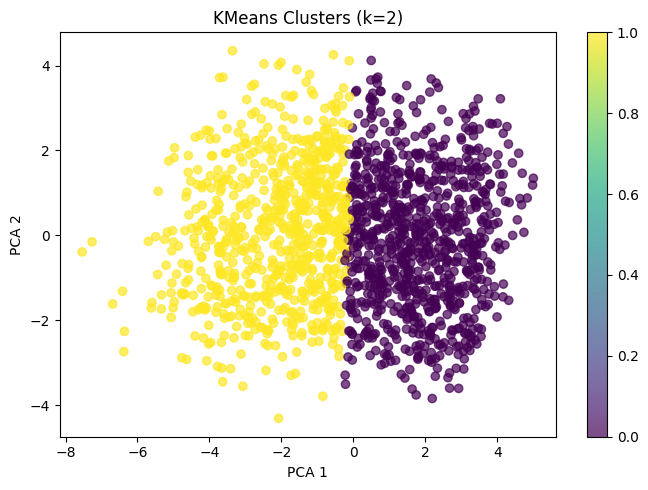

C:\Users\jerem\AppData\Local\Temp\ipykernel_18624\143243356.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 700x500 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label="Cluster")


<Figure size 640x480 with 0 Axes>

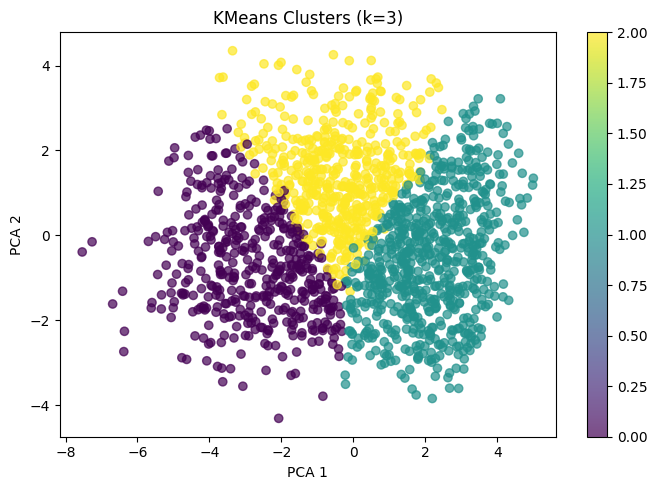

C:\Users\jerem\AppData\Local\Temp\ipykernel_18624\143243356.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 700x500 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label="Cluster")


<Figure size 640x480 with 0 Axes>

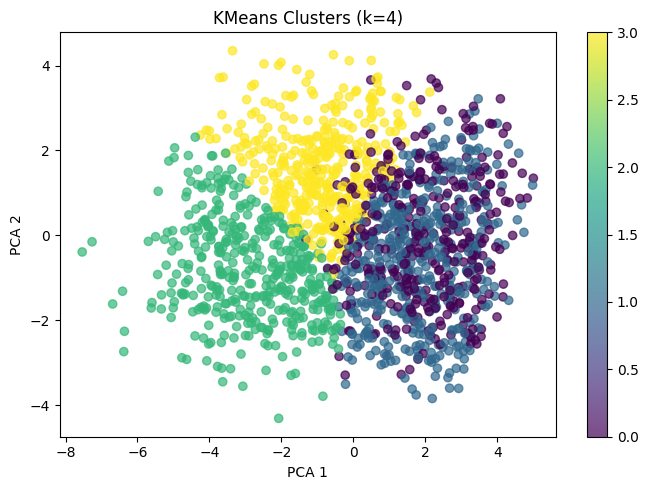

C:\Users\jerem\AppData\Local\Temp\ipykernel_18624\143243356.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 700x500 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label="Cluster")


<Figure size 640x480 with 0 Axes>

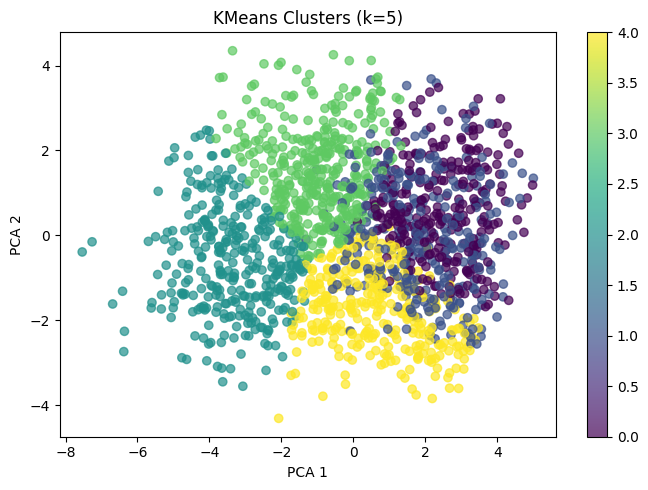

C:\Users\jerem\AppData\Local\Temp\ipykernel_18624\143243356.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 700x500 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label="Cluster")


<Figure size 640x480 with 0 Axes>

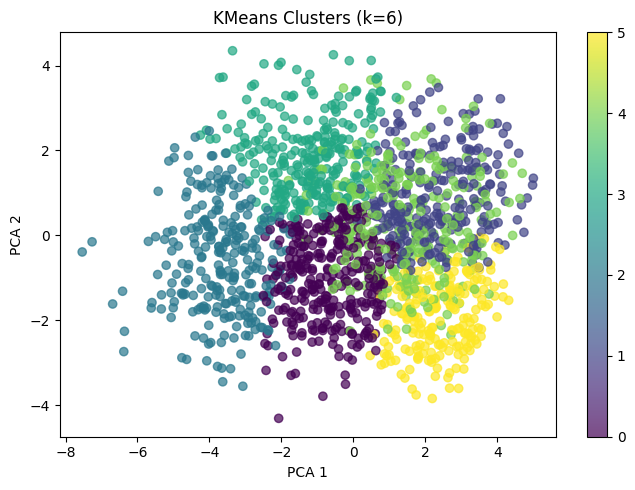

C:\Users\jerem\AppData\Local\Temp\ipykernel_18624\143243356.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 700x500 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label="Cluster")


<Figure size 640x480 with 0 Axes>

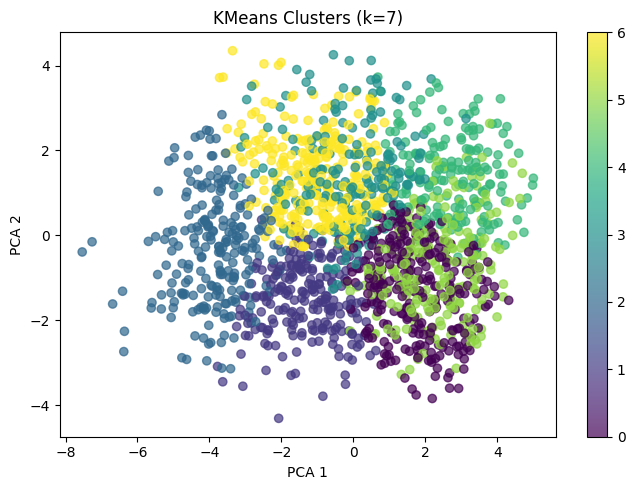

C:\Users\jerem\AppData\Local\Temp\ipykernel_18624\143243356.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 700x500 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label="Cluster")


<Figure size 640x480 with 0 Axes>

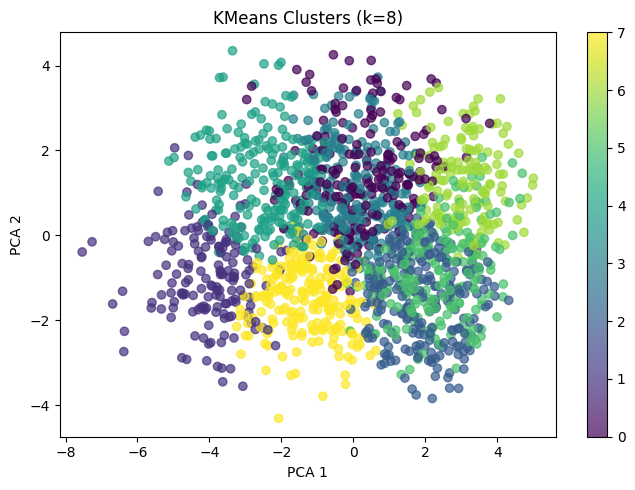

C:\Users\jerem\AppData\Local\Temp\ipykernel_18624\143243356.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 700x500 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label="Cluster")


<Figure size 640x480 with 0 Axes>

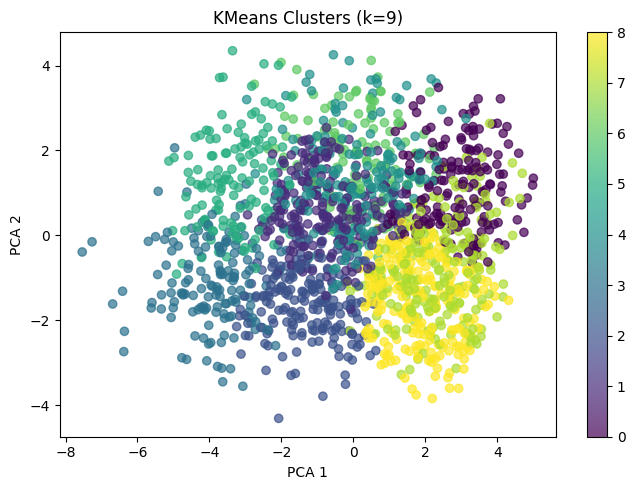

C:\Users\jerem\AppData\Local\Temp\ipykernel_18624\143243356.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 700x500 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label="Cluster")


<Figure size 640x480 with 0 Axes>

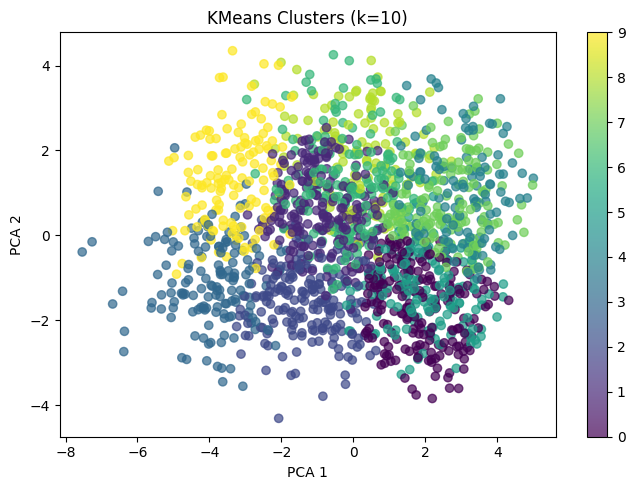

C:\Users\jerem\AppData\Local\Temp\ipykernel_18624\143243356.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 700x500 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label="Cluster")


<Figure size 640x480 with 0 Axes>

KMeans Clustering Results:
k=2, silhouette_score=0.230, inertia=17881.30
k=3, silhouette_score=0.174, inertia=15919.19
k=4, silhouette_score=0.168, inertia=14350.78
k=5, silhouette_score=0.157, inertia=13285.08
k=6, silhouette_score=0.143, inertia=12527.19
k=7, silhouette_score=0.147, inertia=11886.98
k=8, silhouette_score=0.139, inertia=11387.16
k=9, silhouette_score=0.141, inertia=10910.84
k=10, silhouette_score=0.141, inertia=10500.94


In [6]:
results = []

for k in range(2, 11):
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    
    results.append({
        "k": k,
        "silhouette_score": sil_score,
        "inertia": kmeans.inertia_
    })
    
    # Plot
    plt.figure(figsize=(7,5))
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="viridis",
        alpha=0.7
    )
    
    plt.title(f"KMeans Clusters (k={k})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.colorbar(scatter)
    plt.tight_layout()
    plt.show()


    plt.colorbar(scatter, label="Cluster")
    plt.show()

print("KMeans Clustering Results:")
for result in results:
    print(f"k={result['k']}, silhouette_score={result['silhouette_score']:.3f}, inertia={result['inertia']:.2f}")

## 6.3 Hierarchical

Compute Linkage Matrix

In [7]:
Z = linkage(X_scaled, method="ward")

Plot Dendrogram

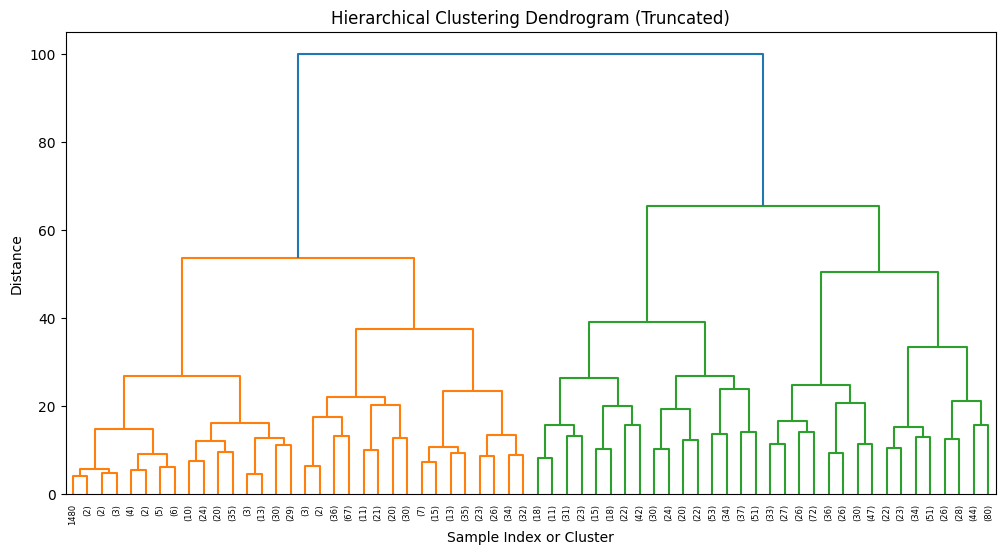

In [8]:
plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Sample Index or Cluster")
plt.ylabel("Distance")
plt.show()

In [9]:
results = []

for k in range(2, 11):
    
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = model.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    
    results.append({
        "k": k,
        "silhouette_score": sil_score
    })

results_df = pd.DataFrame(results)
print(results_df)

    k  silhouette_score
0   2          0.186888
1   3          0.150958
2   4          0.135236
3   5          0.106912
4   6          0.111960
5   7          0.105033
6   8          0.095948
7   9          0.095401
8  10          0.097140


## 6.5 PCA + Visualization